In [1]:
import torch
import torch.nn as nn
import numpy as np

In [2]:
class PhInn(nn.Module):
    def __init__(self):
        super().__init__()
        self.n=nn.Sequential(nn.Linear(2,64),nn.Tanh(),
                            nn.Linear(64,64),nn.Tanh(),
                            nn.Linear(64,1))
    def forward(self,x,t):
        inp=torch.cat([x,t],dim=1)
        return self.n(inp)

In [3]:
def loss(mod,x,t,alp=0.001):
    x.requires_grad_(True)
    t.requires_grad_(True)
    o=mod(x,t)
    ot=torch.autograd.grad(o,t,grad_outputs=torch.ones_like(o),create_graph=True)[0]
    ox=torch.autograd.grad(o,x,grad_outputs=torch.ones_like(o),create_graph=True)[0]
    oxx=torch.autograd.grad(ox,x,grad_outputs=torch.ones_like(ox),create_graph=True)[0]
    l=ot-alp*oxx
    return torch.mean(l**2)

In [4]:
def boud(mod,x,t):
    o=mod(x,t)
    return torch.mean(o**2)

In [5]:
def inil(mod,x):
    t0=torch.zeros_like(x)
    o=mod(x,t0)
    ot=torch.sin(np.pi*x)
    return torch.mean((o-ot)**2)

In [6]:
def sample(n=1000):
    x=torch.rand(n,1)
    t=torch.rand(n,1)
    return x,t

In [7]:
def sampbo(n=200):
    t=torch.rand(n,1)
    x0=torch.zeros(n,1)
    x1=torch.ones(n,1)
    return x0,x1,t

In [8]:
def sampin(n=200):
    return torch.rand(n,1)

In [9]:
mod=PhInn()
optim=torch.optim.Adam(mod.parameters(),lr=1e-3)

In [10]:
for ep in range(5001):
    xf,tf=sample()
    x0,x1,tb=sampbo()
    xi=sampin()
    losss=loss(mod,xf,tf)
    lossb=boud(mod,x0,tb)+boud(mod,x1,tb)
    lossi=inil(mod,xi)
    losst=losss+lossb+lossi
    optim.zero_grad()
    losst.backward()
    optim.step()
    if ep%500==0:
        print(f'{ep}: {losst.item():.6f}')

0: 0.459054
500: 0.001208
1000: 0.000131
1500: 0.000129
2000: 0.000095
2500: 0.000084
3000: 0.000017
3500: 0.000018
4000: 0.000012
4500: 0.000019
5000: 0.000012


In [11]:
def true(x,t,alp=0.001):
    return torch.exp(-np.pi**2 * alp *t)*torch.sin(np.pi*x)

In [16]:
xt=torch.linspace(0,1,100).view(-1,1)
tt=torch.ones_like(xt)*0.5
op=mod(xt,tt).detach()
ot=true(xt,tt)
e=torch.mean((op-ot)**2)
print(f'{e.item():.6f}')

0.000009


In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [18]:
def create_grid(n=100):
    x = torch.linspace(0, 1, n)
    t = torch.linspace(0, 1, n)
    X, T = torch.meshgrid(x, t, indexing='ij')
    X_flat = X.reshape(-1, 1)
    T_flat = T.reshape(-1, 1)
    return X, T, X_flat, T_flat

In [19]:
X, T, X_flat, T_flat = create_grid()
with torch.no_grad():
    U_pred = mod(X_flat, T_flat).reshape(X.shape)
    U_true = true(X_flat, T_flat).reshape(X.shape)
error = torch.abs(U_pred - U_true)

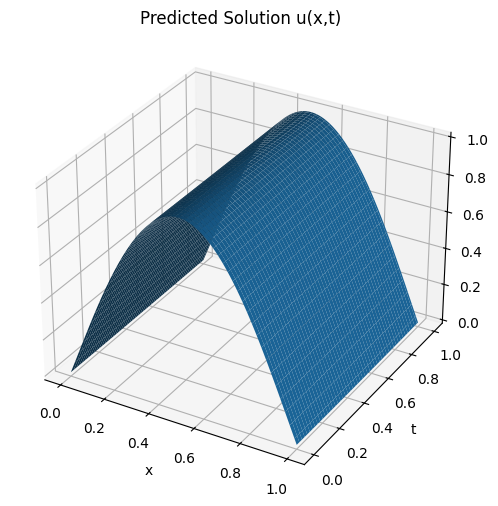

In [20]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X.numpy(), T.numpy(), U_pred.numpy())
ax.set_title("Predicted Solution u(x,t)")
ax.set_xlabel("x")
ax.set_ylabel("t")

plt.show()

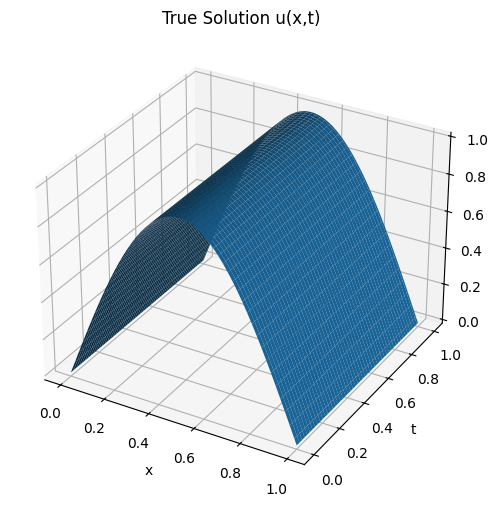

In [21]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X.numpy(), T.numpy(), U_true.numpy())
ax.set_title("True Solution u(x,t)")
ax.set_xlabel("x")
ax.set_ylabel("t")

plt.show()

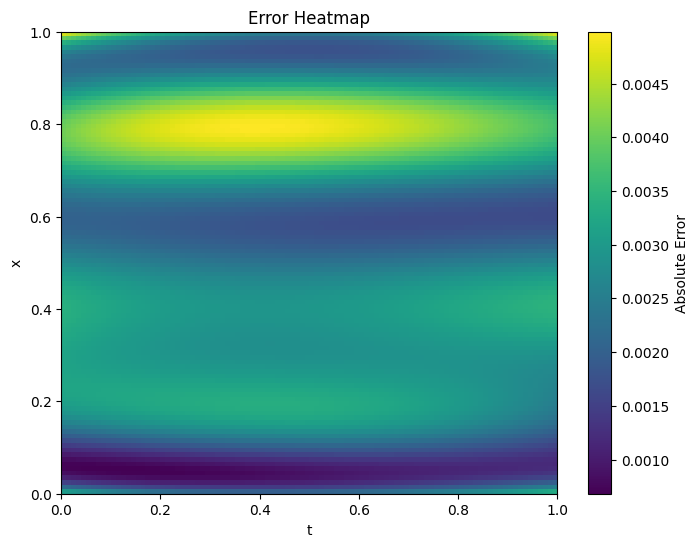

In [22]:
plt.figure(figsize=(8,6))
plt.imshow(error.numpy(), extent=[0,1,0,1], origin='lower', aspect='auto')
plt.colorbar(label="Absolute Error")
plt.title("Error Heatmap")
plt.xlabel("t")
plt.ylabel("x")

plt.show()